<a href="https://colab.research.google.com/github/Marlon-Sbardelatti/machine-learning/blob/feature%2Ftrabalho-04/trabalho-04/neural_network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> **Equipe**: 01<br>
> **Estudantes**: Cristina Siewert Jansen, Marlon Sbardelatti e Sofia Sousa Lindner<br>
> **Link do vídeo**: https://youtu.be/AeQ6Lqs-dKU

# **REDES NEURAIS ARTIFICIAIS**

# PARTE 1: Classificação Binária - Diagnóstico de Câncer de Mama

Base de dados: Breast Cancer Wisconsin (Diagnostic) -
https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic

In [ ]:
# Instala bilbiotecas Keras e Tensorflow
!pip install scikeras==0.13.0

In [ ]:
!pip install tensorflow==2.21.0 scikit-learn==1.9.0

In [ ]:
# após instalar as bibliotecas, é necessário reiniciar o notebook
# Para isso, rode esta célula sozinha antes de prosseguir.
exit()

In [ ]:
import pandas as pd
import tensorflow as tf
import sklearn
import scikeras

In [ ]:
# Exibe versões das bibliotecas instaladas
pd.__version__, tf.__version__, sklearn.__version__, scikeras.__version__

('2.2.2', '2.21.0', '1.9.0', '0.13.0')

### Carregar os dados

**1) Carregue a base de dados, faça a divisição de treino e teste (para isso, utilize a função train_test_split do sklearn), como o tamanho da base de teste de 0.25.**

In [ ]:
from sklearn.model_selection import train_test_split

# Lê arquivos CSV
breast_data = pd.read_csv('dados_breast.csv')
breast_labels = pd.read_csv('rotulos_breast.csv')

# Converte para ndarray em X e y
X = breast_data.values
y = breast_labels.values

# Separa dataset em conjunto de treino e teste (25%)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
)

# Exibe dimensões do conjunto de treino
X_train.shape, y_train.shape

((426, 30), (426, 1))

In [ ]:
# Exibe dimensões do conjunto de teste
X_test.shape, y_test.shape

((143, 30), (143, 1))

Ambos os conjuntos têm duas dimensões: número de amostras, número de colunas. No caso do eixo X, as 30 colunas representam features distintas das amostras de entrada. No caso do eixo y, há apenas uma coluna, que é associada ao rótulo de cada amostra.

A separação de 426 amostras para treino e 143 amostras para teste confirma a separação escolhida de 25%, visto que 426 + 143 = 569 (total) e 569 × 0.25 ≈ 143.

### Estrutura da Rede Neural Artificial e Teste

In [ ]:
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import cross_val_score
from tensorflow.keras.models import Sequential
import tensorflow as tf
from tensorflow.keras import backend as k

**2) Crie a RNA com as seguintes configurações:**

**a) uma camada de entrada de com 30 neurônios;**

**b) uma camada oculta densa com 16 neurônios. Porque a camada oculta tem essa quantidade de neurônios?**

**c) adicione na camada oculta a função de ativação relu e inicialize os pesos de utilize o Random uniform initializer (https://www.tensorflow.org/api_docs/python/tf/keras/initializers);**

**d) adicione a camada de saíde com a função de ativação sigmoid. Porque foi utilizada esta função para a saída da RNA?**

In [ ]:
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.initializers import RandomUniform

ENTRY_LAYER_SIZE = 30
HIDDEN_LAYER_SIZE = 16

# c) Inicializador dos pesos aleatórios da camada oculta
initializer = RandomUniform(minval=0.0, maxval=1.0)

neural_network = Sequential([
    # a) Camada de Entrada
    Input(shape=(ENTRY_LAYER_SIZE,)),

    # b) Camada Oculta
    Dense(units=HIDDEN_LAYER_SIZE, activation='relu', kernel_initializer=initializer),

    # d) Camada de Saída: Sigmoid para classificação binária
    Dense(units=1, activation='sigmoid')
])

classifier = KerasClassifier(
    model=neural_network,
    verbose=0
)

**b) uma camada oculta densa com 16 neurônios. Porque a camada oculta tem essa quantidade de neurônios?**<br>
Porque o número de neurônios da camada oculta é: nº de neurônios de entrada + nº de saídas / 2.<br>
Dessa forma, temos: (30 + 2) / 2 = 32 / 2 = 16.


**d) adicione a camada de saída com a função de ativação sigmoid. Porque foi utilizada esta função para a saída da RNA?**<br>
Porque a classificação é binária, ou seja, só existem duas classes possíveis: 0 (Sem câncer) ou 1 (Com câncer). Sendo assim, a função sigmoide por padrão utiliza o limiar 0.5, o que permite a classificação em exatas duas classes.

**3) Porque utilizamos a classe chamada Sequential para a RNA?**<br>
A classe Sequential permite a definição de camadas sequenciais à rede, o que altera completamente sua arquitetura e comportamento, visto que o resultado de cada camada é utilizado na próxima. Ou seja, para definirmos que os resultados perpassam camada de entrada, oculta e saída sequencialmente, precisamos utilizar o Sequential.

**4) A partir da RNA gerada, explique o que são os valores apresentados na tabela da rede_neural.summary()**<br>
São apresentadas as camadas oculta e de saída da rede, bem como a quantidade de parâmetros e saídas de cada uma. Naturalmente, a camada oculta produz 16 saídas porque contém 16 neurônios, enquanto a camada de saída produz apenas uma: a classe.<br>
A coluna `Param #` representa o número de parâmetros ajustáveis da rede, isto é, os pesos e os biases aprendidos durante o treinamento. Na primeira camada densa, considerando 30 entradas e 16 neurônios, existem 30 × 16 = 480 pesos e 16 biases, totalizando 496 parâmetros. Na camada de saída, os 16 neurônios da camada anterior são conectados ao único neurônio de saída, gerando 16 pesos e 1 bias, totalizando 17 parâmetros. Assim, a rede possui 513 parâmetros treináveis ao todo.

In [ ]:
neural_network.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 513 (2.00 KB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 0 (0.00 B)

**5) Adicione um otimizador Adam (https://www.tensorflow.org/api_docs/python/tf/keras/optimizers) e especifique a classe loss binário - binary crossentropy (https://www.tensorflow.org/api_docs/python/tf/keras/losses) e a classe metrics para utilizar a métrica de avaliação de acurácia binária (https://www.tensorflow.org/api_docs/python/tf/keras/metrics)**

In [ ]:
# Compila rede com função de perda binária e acurácia binária como métrica de validação
neural_network.compile(optimizer='adam', loss='binary_crossentropy', metrics=['binary_accuracy'])

**6) Para que servem os otimizadores? Como o otimizador Adam funciona?**

Os otimizadores têm a função de atualizar os pesos da rede neural ao longo do treinamento, com o objetivo de minimizar a função de perda e melhorar a precisão das previsões.

O algoritmo Adam (Adaptive Moment Estimation) ajusta automaticamente as taxas de aprendizado para cada parâmetro da rede neural combinando duas técnicas clássicas: Momentum e RMSprop. Ele utiliza estimativas da média dos gradientes e da variância dos gradientes para adaptar automaticamente a taxa de aprendizado para cada peso individual do modelo. Essa abordagem proporciona uma convergência mais rápida e estável, tornando o Adam um dos métodos de otimização mais utilizados em problemas de aprendizado profundo.

**7) Depois de estruturados os parâmtros da RNA, utilize a função .fit para fazer o treinamento da rede. Como foi utilizado o otimizador Adam, e ele é baseado na descida do gradiente estocástica, é possível definir a quantidade de registros que serão enviados para a RNA, isto é, em cada batch serão utilizados 10 registros. Quantos batches serão utilizados ao total?**

Como o número de registros do conjunto de treinamento é 426 e o `batch_size` é 10, o total de batches **por época** pode ser dado por 426 / 10 ≈ 43. Finalmente, considerando que o treinamento definiu o valor arbitrário de 100 épocas, serão utilizados 43 × 100 = 4300 batches ao longo de todo o treinamento.

**8) Por fim, defina o número de épocas em que ocorre o treinamento igual a 100.**

In [ ]:
# Realiza treinamento do modelo com 100 épocas
neural_network.fit(X_train, y_train, batch_size=10, epochs=100)

Epoch 1/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - binary_accuracy: 0.5329 - loss: 119.1982
Epoch 2/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.5634 - loss: 71.9763
Epoch 3/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.5493 - loss: 52.7253
Epoch 4/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.5986 - loss: 40.3398
Epoch 5/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.5751 - loss: 27.9252
Epoch 6/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.6268 - loss: 18.2498
Epoch 7/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.6925 - loss: 7.4194 
Epoch 8/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.7934 - loss: 3.8340
Epoch 9/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.7465 - loss: 4.6948
Epoch 10/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.7911 - loss: 2.5847
Epoch 11/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy:

**9) Crie uma variável chamada previsoes para realizar a previsão dos dados de teste (X_teste) O resultado da rede deve ser um valor entre 0 e 1. Porque isso acontece?** <br>

Como estamos usando a função de ativação sigmoid na camada de saída da rede, o resultado da previsão será uma probabilidade entre 0 (0%) e 1 (100%). Ainda que o problema seja de classificação binária, o threshold de 0.5 só é utilizado após previsão, de modo que saídas > 0.5 = 1 e saídas <= 0.5 = 0. Isto porque, se não fosse um problema do gênero, a utilização de outro threshold permitira dividir em mais classes o resultado.

In [ ]:
# Realiza previsão para conjunto de teste
predictions = neural_network.predict(X_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


**10) Converta o resultado que está em probabilidade para valores binários com um limiar (treshold) de 0.5**.

In [ ]:
# Conversão das previsões para classes binárias: 0 (False) ou 1 (True)
predictions = predictions > 0.5

In [ ]:
predictions

array([[False],
       [False],
       [False],
       [ True],
       [ True],
       [ True],
       [ True],
       [False],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [False],
       [ True],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [False],
       [ True],
       [

**9) Explique o resultado da RNA.** <br>

A RNA, apesar de ter utilizado 100 épocas para treinamento, apresentou um resultado intermediário de acurácia, de 86,71%, e perda, de 2. Provavelmente isso se deve à arquitetura da rede, que utiliza apenas uma camada oculta (Perceptron). A taxa relativamente baixa de perda revela que o otimizador foi importante durante o processo de treinamento, ainda que talvez não tenha a configuração ideal para alcançar melhor eficiência da rede.

In [ ]:
neural_network.evaluate(X_test, y_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - binary_accuracy: 0.8601 - loss: 1.3504


[1.3503977060317993, 0.8601398468017578]

## Camadas e Otimização da RNA

**10) Adicione mais uma camada para oculta densa com 16 neurônio com a função de ativação relu e inicialize os pesos de utilize o Random uniform initializer. Qual o total de parâmetros da RNA agora?**<br>

O total de parâmetros agora é de 785.

In [ ]:
# Recriação da rede com uma camada oculta a mais
neural_network = Sequential([
    Input(shape=(ENTRY_LAYER_SIZE,)),

    # Duas camadas ocultas com 16 neurônios
    Dense(units=HIDDEN_LAYER_SIZE, activation='relu', kernel_initializer=initializer),
    Dense(units=HIDDEN_LAYER_SIZE, activation='relu', kernel_initializer=initializer),

    Dense(units=1, activation='sigmoid')
])

classifier = KerasClassifier(
    model=neural_network,
    verbose=0
)

neural_network.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 785 (3.07 KB)

 Trainable params: 785 (3.07 KB)

 Non-trainable params: 0 (0.00 B)

**11) Abaixo são adicionados os parâmetros do otimizador, que são a taxa de aprendizado e o clipvalue. O que eles fazem?** <br>

A taxa de aprendizado (learning rate) determina o tamanho dos ajustes realizados nos pesos da rede a cada atualização. Valores maiores permitem um aprendizado mais rápido, mas podem fazer com que o modelo não converja para a solução ideal. Já valores muito pequenos tornam o treinamento mais lento. No código foi utilizada uma taxa de aprendizado de 0.001, que é um valor comum por proporcionar estabilidade ao treinamento.

O clipvalue é um mecanismo de gradient clipping que limita o valor máximo dos gradientes durante a atualização dos pesos. Com clipvalue = 0.5, qualquer gradiente com magnitude superior a 0.5 é truncado para esse limite. Isso evita o problema de explosão dos gradientes, tornando o treinamento mais estável e reduzindo oscilações excessivas na otimização.

In [ ]:
# Compilação da rede com learning rate e clipvalue
optimizer = tf.keras.optimizers.Adam(learning_rate = 0.001, clipvalue = 0.5)
neural_network.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['binary_accuracy'])

**12) Teste novamente a RNA. Aumentar a quantidade de camadas melhorou ou piorou os resultados? Explique o que aconteceu com a RNA e porque.**<br>
Ao aumentar a quantidade de camadas ocultas, a acurácia caiu para 62%, enquanto a taxa de perda (loss) aumentou para aproximadamente 43. Ou seja, a rede apresentou desempenho inferior à anterior. Ao aumentar sua capacidade de aprendizado com mais uma camada de neurônios, a rede se tornou mais suscetível ao **overfitting**, porque criou uma dependência entre os neurônios da primeira camada oculta com os da segunda, de modo que acabasse memorizando ruídos em vez de aprender padrões generalizáveis.

In [ ]:
neural_network.fit(X_train, y_train, batch_size=10, epochs=100)

Epoch 1/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - binary_accuracy: 0.6315 - loss: 21438.4766
Epoch 2/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.6315 - loss: 11012.7627
Epoch 3/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.5845 - loss: 2531.6165
Epoch 4/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.5493 - loss: 91.8359 
Epoch 5/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.6033 - loss: 45.5614
Epoch 6/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.5939 - loss: 47.1130
Epoch 7/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.6667 - loss: 23.6310
Epoch 8/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.6455 - loss: 18.7948
Epoch 9/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.6690 - loss: 22.1800
Epoch 10/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.6221 - loss: 39.0589
Epoch 11/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binar

In [ ]:
predictions = neural_network.predict(X_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


In [ ]:
neural_network.evaluate(X_test, y_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - binary_accuracy: 0.6224 - loss: 43.7100


[43.71004867553711, 0.6223776340484619]

## K-Fold Cross Validation

In [ ]:
# Importa recursos necessários das bibliotecas
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import cross_val_score
from tensorflow.keras.models import Sequential
from tensorflow.keras import backend as k
from tensorflow.keras.layers import Dense, Dropout, InputLayer

In [ ]:
'''
Função que cria e compila uma rede neural com as mesmas configurações da anterior:
  - 1 camada de entrada com 30 neurônios
  - 2 camadas ocultas densas com 16 neurônios e função ReLU
  - 1 camada de saída com função sigmoid

Foi adicionado um parâmetro opcional de dropout para reutilização em outras
questões.
'''
def create_network():
  k.clear_session()
  neural_network = Sequential([
      tf.keras.layers.InputLayer(shape=(30,)),
      tf.keras.layers.Dense(units=16, activation='relu', kernel_initializer='random_uniform'),
      tf.keras.layers.Dense(units=16, activation='relu', kernel_initializer='random_uniform'),
      tf.keras.layers.Dense(units=1, activation = 'sigmoid')])
  optimizer = tf.keras.optimizers.Adam(learning_rate = 0.001, clipvalue = 0.5)
  neural_network.compile(optimizer = optimizer, loss = 'binary_crossentropy', metrics = ['binary_accuracy'])
  return neural_network

**13) Assista o vídeo https://youtu.be/RczbeFs_WbQ?si=f1Yu4LZaGDfZZpbZ para compreender melhor sobre como funciona o k-fold cross validation. Explique como esta rede foi configurada e como é possível chegar no resultado dela. O que é necessário fazer?**<br>
A rede é criada seguindo o mesmo padrão anterior, ou seja:
1. Uma camada de entrada com 30 neurônios
2. Duas camadas ocultas com 16 neurônios
3. Uma camada de saída que utiliza sigmoide como função de ativação

Além de utilizar o otimizador Adam, `batch_size` com valor 10 e 100 épocas de treinamento.

Em relação ao K-Fold, é necessário chamar a função **cross_val_score** que recebe como paramêtro `cv`, responsável por definir o total de folds. Na implementação atual é definido cv=10. Portanto, em cada execução, 9 partes são utilizadas para treinamento e 1 parte é utilizada para validação. Esse processo é repetido 10 vezes, alternando a parte utilizada para teste, de modo que todas as amostras sejam avaliadas uma vez.

In [ ]:
# Cria classificador com nova função de criação da rede, sem dropout
neural_network = KerasClassifier(model = create_network, epochs = 100, batch_size = 10)

In [ ]:
# Calcula cross validation com 10 folds
resultados = cross_val_score(estimator = neural_network, X = X, y = y, cv = 10, scoring = 'accuracy')

Epoch 1/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - binary_accuracy: 0.5801 - loss: 1.1976
Epoch 2/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.6953 - loss: 0.5869
Epoch 3/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.7637 - loss: 0.4875
Epoch 4/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.7969 - loss: 0.4501
Epoch 5/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.8281 - loss: 0.4086
Epoch 6/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.8223 - loss: 0.4891
Epoch 7/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.8203 - loss: 0.4452
Epoch 8/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.8496 - loss: 0.4218
Epoch 9/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.8281 - loss: 0.5302
Epoch 10/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.8535 - loss: 0.4624
Epoch 11/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.8379 

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Epoch 1/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - binary_accuracy: 0.7168 - loss: 0.7541
Epoch 2/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.8145 - loss: 0.4596
Epoch 3/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.8047 - loss: 0.4430
Epoch 4/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.8574 - loss: 0.3881
Epoch 5/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.8203 - loss: 0.4456
Epoch 6/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.8691 - loss: 0.3679
Epoch 7/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.8438 - loss: 0.3976
Epoch 8/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.7988 - loss: 0.5345
Epoch 9/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.8340 - loss: 0.6049
Epoch 10/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.8379 - loss: 0.4462
Epoch 11/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Epoch 1/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - binary_accuracy: 0.6270 - loss: 0.6961
Epoch 2/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.7539 - loss: 0.4939
Epoch 3/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.7500 - loss: 0.5167
Epoch 4/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.8223 - loss: 0.4434
Epoch 5/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.8555 - loss: 0.3887
Epoch 6/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.8496 - loss: 0.3767
Epoch 7/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.8457 - loss: 0.3962
Epoch 8/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.8164 - loss: 0.4913
Epoch 9/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.8574 - loss: 0.3768
Epoch 10/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.8477 - loss: 0.3991
Epoch 11/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
# Exibe resultados da cross validation
resultados

array([0.56140351, 0.80701754, 0.96491228, 0.73684211, 0.66666667,
       0.84210526, 0.8245614 , 0.71929825, 0.8245614 , 0.73214286])

**14) Calcule também o Desvio Padrão dos resultados para avaliar o modelo. O que é possível concluir com esse resultado?**

O desvio padrão mede a variação do desempenho do modelo de acordo com os subconjuntos. Quanto menor seu valor, mais consistente poderia ser considerado o modelo, pois indicaria resultado semelhante independentemente da divisão de dados.

O desvio padrão calculado foi de 10,48%, o que significa que o modelo ainda apresenta grande variação de eficiência a depender do conjunto utilizado para validação. Isso pode ser observado pela divergência entre a acurácia de alguns dos folds, que varia de 56,1% até 96,5%.

Ou seja, embora a média das acurácias possa indicar um desempenho satisfatório, o desvio padrão elevado mostra que a capacidade de generalização do modelo ainda não é totalmente estável.

In [ ]:
import numpy as np

# Calcula desvio padrão do K-Fold
standard_deviation = np.std(resultados)

# Exibe desvio padrão
standard_deviation

np.float64(0.10476914169131389)

## Overfitting e Dropout

**15) Como vimos, o modelo anterior sofreu overfitting. Para reduzir esse problema, aplicamos a técnica de regularização conhecida como dropout (artigo oficial: https://www.cs.toronto.edu/~rsalakhu/papers/srivastava14a.pdf e explicação em português: https://www.deeplearningbook.com.br/como-funciona-o-dropout/ ). Aplique o dropout de 20% na primeira e segunda camada oculta. O que acontece com os resultados? E o Desvio Padrão?**

In [ ]:
def create_network():
  k.clear_session()
  neural_network = Sequential([
      tf.keras.layers.InputLayer(shape=(30,)),
      tf.keras.layers.Dense(units=16, activation='relu', kernel_initializer='random_uniform'),
      tf.keras.layers.Dropout(rate=0.2),
      tf.keras.layers.Dense(units=16, activation='relu', kernel_initializer='random_uniform'),
      tf.keras.layers.Dropout(rate=0.2),
      tf.keras.layers.Dense(units=1, activation = 'sigmoid')])
  optimizer = tf.keras.optimizers.Adam(learning_rate = 0.001, clipvalue = 0.5)
  neural_network.compile(optimizer = optimizer, loss = 'binary_crossentropy', metrics = ['binary_accuracy'])
  return neural_network

In [ ]:
# Recria o modelo dessa vez com camadas de Dropout de 20%
neural_network = KerasClassifier(model = create_network, epochs = 100, batch_size = 10)

In [ ]:
# Recalcula cross validation
results = cross_val_score(estimator=neural_network, X=X, y=y, cv=10, scoring='accuracy')

Epoch 1/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - binary_accuracy: 0.5684 - loss: 1.1577
Epoch 2/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.6934 - loss: 0.6597
Epoch 3/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.7188 - loss: 0.5345
Epoch 4/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.7285 - loss: 0.5825
Epoch 5/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.7598 - loss: 0.5279
Epoch 6/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.7754 - loss: 0.5551
Epoch 7/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.7773 - loss: 0.5155
Epoch 8/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.7891 - loss: 0.5018
Epoch 9/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.7871 - loss: 0.5509
Epoch 10/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.7891 - loss: 0.6172
Epoch 11/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.7598 

In [ ]:
# Exibe resultados da cross validation com Dropout na rede
results

array([0.73684211, 0.9122807 , 0.92982456, 0.78947368, 0.9122807 ,
       0.9122807 , 0.9122807 , 0.94736842, 0.84210526, 0.98214286])

In [ ]:
standard_deviation = np.std(results)
standard_deviation

np.float64(0.07152376395512877)

Com a adição de camadas com 20% de dropout após cada camada oculta, o desvio padrão diminuiu para 7,15%. Isso demonstra que o modelo passou a ter maior estabilidade em relação a variações na divisão dos dados para validação.

Houve também menor diferença entre os folds. Dessa vez, seu desempenho variou de 73,68% a 98,2%, e vários folds alcançaram valores superiores a 90%.

Isso indica que o uso do Dropout reduziu o overfitting e melhorou a capacidade de generalização do modelo.

## Tuning dos Hiperparâmetros (técnicas de ajuste)

Hyperparameter Tuning (Ajuste de Hiperparâmetros) é o processo geral de encontrar os melhores valores para os hiperparâmetros de um modelo de machine learning.
Exemplos de hiperparâmetros:

- Taxa de aprendizado (learning rate)

- Número de árvores em um RandomForest

- Número de camadas ou neurônios em uma rede neural

- Tipo de kernel em um SVM

O tuning pode ser feito por diferentes técnicas, como:

- Grid Search

- Random Search

- Bayesian Optimization, etc.

**16) Descreva como a RNA foi configurada para fazer o processo de tuning.**

A rede é criada em partes de maneira igual, mesmas camadas e dropouts. Porém agora a função que cria a rede recebe os hiperparamêtros. Criamos **params** que serão testados utilizando Grid Search, optamos por utilizar a segunda versão do params que conta com menos opções pois a primeira acaba crashando a execução após algumas épocas de treinamento.<br>

Os melhores paramêtros encontrados foram: <br>
1. batch_size: 10
2. epochs: 50
3. model__activation: 'relu'
4. model__kernel_initializer: random_uniform
5. model__loss: binary_crossentropy
6. model__neurons: 16
7. model__optimizer: 'adam'

E que com eles foi possível obter uma acurácia de aproximadamente 89%.


In [ ]:
def create_network(optimizer, loss, kernel_initializer, activation, neurons):
  k.clear_session()
  rede_neural = Sequential([
      tf.keras.layers.InputLayer(shape=(30,)),
      tf.keras.layers.Dense(units=neurons, activation=activation, kernel_initializer=kernel_initializer),
      tf.keras.layers.Dropout(rate = 0.2),
      tf.keras.layers.Dense(units=neurons, activation=activation, kernel_initializer=kernel_initializer),
      tf.keras.layers.Dropout(rate = 0.2),
      tf.keras.layers.Dense(units=1, activation = 'sigmoid')])
  rede_neural.compile(optimizer = optimizer, loss = loss, metrics = ['binary_accuracy'])
  return rede_neural

In [ ]:
neural_network = KerasClassifier(model=create_network)

In [ ]:
params = {
    'batch_size': [10, 30],
    'epochs': [50, 100],
    'model__optimizer': ['adam', 'sgd'],
    'model__loss': ['binary_crossentropy', 'hinge'],
    'model__kernel_initializer': ['random_uniform', 'normal'],
    'model__activation': ['relu', 'tanh'],
    'model__neurons': [16, 8]
}

In [ ]:
#caso tiver problema com a configuração anterior, testar essa
params = {
    'batch_size': [10, 30],
    'epochs': [50],
    'model__optimizer': ['adam'],
    'model__loss': ['binary_crossentropy'],
    'model__kernel_initializer': ['random_uniform', 'normal'],
    'model__activation': ['relu'],
    'model__neurons': [16]
}

In [ ]:
params

{'batch_size': [10, 30],
 'epochs': [50],
 'model__optimizer': ['adam'],
 'model__loss': ['binary_crossentropy'],
 'model__kernel_initializer': ['random_uniform', 'normal'],
 'model__activation': ['relu'],
 'model__neurons': [16]}

In [ ]:
from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(estimator = neural_network, param_grid = params,
                          scoring = 'accuracy', cv = 5)

In [ ]:
grid_search = grid_search.fit(X, y)

Epoch 1/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - binary_accuracy: 0.5582 - loss: 1.3597
Epoch 2/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.6220 - loss: 0.6493
Epoch 3/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.7121 - loss: 0.5559
Epoch 4/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.6769 - loss: 0.5551
Epoch 5/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.7473 - loss: 0.4934
Epoch 6/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.7604 - loss: 0.5037
Epoch 7/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.7912 - loss: 0.4535
Epoch 8/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.7868 - loss: 0.4716
Epoch 9/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.8088 - loss: 0.4261
Epoch 10/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.7802 - loss: 0.4340
Epoch 11/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.8396 - loss: 0.4

In [ ]:
print(grid_search)

GridSearchCV(cv=5,
             estimator=KerasClassifier(model=<function create_network at 0x7815cce6a3e0>),
             param_grid={'batch_size': [10, 30], 'epochs': [50],
                         'model__activation': ['relu'],
                         'model__kernel_initializer': ['random_uniform',
                                                       'normal'],
                         'model__loss': ['binary_crossentropy'],
                         'model__neurons': [16], 'model__optimizer': ['adam']},
             scoring='accuracy')


In [ ]:
best_params = grid_search.best_params_
print(best_params)

{'batch_size': 10, 'epochs': 50, 'model__activation': 'relu', 'model__kernel_initializer': 'normal', 'model__loss': 'binary_crossentropy', 'model__neurons': 16, 'model__optimizer': 'adam'}


In [ ]:
best_score = grid_search.best_score_
print(best_score)

0.8875019406924392


**17) É possível melhorar ainda mais a curácia da RNA? Como?**

Sim.

Seria possível testar com outras quantidades de neurônios diferentes da sugerida pela fórmula da heurística, com taxas de Dropout diferentes, outro valor de taxa de aprendizado, uso de Early Stopping para interromper treinamento quando não houver mais melhoria, entre outras coisas. O GridSearch retornou uma combinação de hiperparâmetros que não necessáriamente gera o melhor resultado possível.

Porém, antes de alterar o modelo, é interessante avaliar os dados (verificar escalas, variabilidade).

In [ ]:
import pandas as pd

# Estatísticas básicas
breast_data.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,706.771388,19.289649,91.969033,654.889104,4.304801,4.835984,7.489124,2.366459,16.965766,0.851112,...,315.194921,25.677223,107.261213,880.583128,10.633281,25.259112,26.723742,8.745685,30.367174,1.964313
std,2430.243368,4.301036,24.298981,351.914129,21.074558,26.827478,35.618994,16.155145,53.846023,7.103493,...,1655.459336,6.146258,33.602542,569.356993,37.236433,96.473015,114.204035,39.465975,90.748044,14.464355
min,7.760000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.116700,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,12.210000,16.170000,75.170000,420.300000,0.086410,0.065260,0.029580,0.020310,0.163400,0.057800,...,13.180000,21.080000,84.110000,515.300000,0.117800,0.150700,0.116800,0.064990,0.254900,0.071460
50%,13.850000,18.840000,86.240000,551.100000,0.095940,0.094620,0.063870,0.033900,0.181400,0.061660,...,15.150000,25.410000,97.660000,686.500000,0.133800,0.227900,0.249200,0.101500,0.288400,0.080060
75%,17.680000,21.800000,104.100000,782.700000,0.106100,0.132500,0.142500,0.077260,0.203600,0.066400,...,19.850000,29.720000,125.400000,1084.000000,0.150000,0.384200,0.431600,0.170800,0.331800,0.092110
max,9904.000000,39.280000,188.500000,2501.000000,123.000000,277.000000,313.000000,162.000000,304.000000,78.000000,...,9981.000000,49.540000,251.200000,4254.000000,185.000000,1058.000000,1252.000000,291.000000,544.000000,173.000000


Percebe-se que as colunas têm dados muito variados em questão de escala, tanto entre colunas diferentes quanto para a mesma feature (tomando como exemplo radius_mean, cujo valor mínimo é 7.760000 e máximo é 9904.000000).

Assim, testamos se, ao aplicar escala com StandardScaler, o desempenho do modelo seria elevado, sem alterar seus hiperparâmetros.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', neural_network)
])

resultados = cross_val_score(
    pipeline,
    X,
    y,
    cv=10,
    scoring='accuracy'
)

Epoch 1/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.7891 - loss: 0.6484
Epoch 2/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.9297 - loss: 0.4007
Epoch 3/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.9512 - loss: 0.2039
Epoch 4/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.9512 - loss: 0.1510
Epoch 5/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.9531 - loss: 0.1413
Epoch 6/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.9551 - loss: 0.1300
Epoch 7/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.9629 - loss: 0.1206
Epoch 8/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.9668 - loss: 0.1141
Epoch 9/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.9688 - loss: 0.1111
Epoch 10/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.9707 - loss: 0.1014
Epoch 11/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.9668 -

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Epoch 1/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.8496 - loss: 0.6619
Epoch 2/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.9336 - loss: 0.4775
Epoch 3/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.9336 - loss: 0.2755
Epoch 4/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.9414 - loss: 0.1896
Epoch 5/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.9473 - loss: 0.1663
Epoch 6/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.9453 - loss: 0.1505
Epoch 7/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.9570 - loss: 0.1399
Epoch 8/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.9512 - loss: 0.1469
Epoch 9/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.9570 - loss: 0.1236
Epoch 10/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.9609 - loss: 0.1220
Epoch 11/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Epoch 1/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - binary_accuracy: 0.7188 - loss: 0.6405
Epoch 2/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.8945 - loss: 0.4106
Epoch 3/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.9277 - loss: 0.2505
Epoch 4/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.9297 - loss: 0.1918
Epoch 5/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.9453 - loss: 0.1688
Epoch 6/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.9512 - loss: 0.1446
Epoch 7/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.9512 - loss: 0.1470
Epoch 8/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.9551 - loss: 0.1291
Epoch 9/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.9551 - loss: 0.1248
Epoch 10/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.9609 - loss: 0.1202
Epoch 11/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0

In [ ]:
resultados

array([0.87719298, 0.98245614, 0.98245614, 0.92982456, 0.98245614,
       0.98245614, 0.94736842, 0.94736842, 0.92982456, 0.96428571])

In [ ]:
standard_deviation = np.std(resultados)
mean = np.mean(resultados)

standard_deviation, mean

(np.float64(0.032373602000228215), np.float64(0.9525689223057643))

## Para salvar o seu modelo de RNA

In [ ]:
best_model = grid_search.best_estimator_
best_model.model_.save('classificador_breast.keras')


In [ ]:
classificador_novo = tf.keras.models.load_model('/content/classificador_breast.keras')

In [ ]:
classificador_novo.summary()

# PARTE 2: Redes Neurais e CNN - Identificação de Objetos

Neste trabalho iremos fazer a identificação de um conjunto de dados de imagens de artigos de Zalando chamado Fashion-MNIST, que consiste em um conjunto de treinamento de 60.000 exemplos e um conjunto de teste de 10.000 exemplos. Cada exemplo é uma imagem em tons de cinza 28x28, associada a um rótulo de 10 classes.

Fonte: https://www.tensorflow.org/datasets/catalog/fashion_mnist?hl=pt-br

## **ATIVIDADE:**

**Descrição:**

Nesta atividade, você receberá um código de uma Rede Neural Artificial e uma Rede Neural Convolucional (CNN) implementada. Sua tarefa é analisar o código fornecido e fazer uma interpretação detalhada de cada linha, identificando e explicando as principais etapas, camadas e operações realizadas pela RNA e pela CNN.

**Instruções:**

1. Preencha o código com comentários em cada linha, explicando sua função e propósito.
2. Analise o código cuidadosamente para entender como a CNN é configurada.
3. Identifique e explique as camadas de convolução, camadas de pooling, camadas densas, funções de ativação, tamanhos dos filtros, número de neurônios, etc.
4. Identifique quais técnicas de regularização ou otimização formam utilizadas no código e explique como elas contribuem para o desempenho e a generalização do modelo.
5. Comente sobre a função de ativação utilizada na camada de saída.
6. Descreva os hiperparâmetros e ajustes do modelo, como a taxa de aprendizado, número de épocas de treinamento e o tratamento dos conjuntos de dados de treinamento e teste.
7. Faça uma avaliação descritiva dos resultados das Redes Neurais implementadas.



**Entregável:**

Prepare uma análise detalhada do código fornecido, destacando as principais características da CNN e como ela é configurada para a tarefa em questão. Se necessário, inclua observações sobre o potencial de melhoria ou otimização do modelo.

Esta atividade visa consolidar seu conhecimento sobre CNNs, ajudando a compreender como uma Rede Neural Convolucional é implementada e configurada para tarefas específicas.

In [ ]:
# Importa bibliotecas do Tensorflow sobre CNNs
import tensorflow as tf
from tensorflow import keras

In [ ]:
# Importa bibliotecas para manipulação do dataset
import numpy as np                    # Permite transformação dos dados através de tensores
import pandas as pd                   # Permite uso de Dataframes
from matplotlib import pyplot as plt  # Permite plotagem
%matplotlib inline

## Importando base de dados

In [ ]:
# Atribui dataset Fashion-MNIST à variável
fashion_mnist = keras.datasets.fashion_mnist


In [ ]:
# Realiza download do dataset, separando em X (features) e y (labels) de teste e treino
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

In [ ]:

print(X_train_full.shape) # Imprime dimensões do tensor de amostras de TREINO
print(y_train_full.shape) # Imprime total de rótulos de TREINO

print(X_test.shape)       # Imprime dimensões do tensor de amostras de TESTE
print(y_test.shape)       # Imprime total de rótulos de TESTE

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


A saída da célula confirma as informações fornecidas sobre o dataset: `X_train_full` e `X_test` são tensores tridimensionais cujo shape revela, respectivamente, número de amostras, altura e largura de cada imagem, em pixels. A ausência de uma quarta dimensão também confirma o fato de estarem em grayscale.<br>

Dessa forma, pode-se afirmar que o conjunto de treino é composto por 60.000 imagens 28x28, enquanto o conjunto de teste é composto por 10.000 imagens 28x28, o que configura um split de ≈ 15% para teste.

In [ ]:
# Divide eixo X do conjunto de treinamento em: validação e treino
X_valid, X_train = X_train_full[:5000] / 255.0, X_train_full[5000:] / 255.0 # Normaliza intensidade dos pixels
                                                                            # para intervalo [0,1]

# Divide eixo y do conjunto de treinamento em: validação e treino
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

O conjunto original de treinamento é dividido em dois subconjuntos: 5000 imagens são reservadas para validação do modelo, enquanto as 55000 restantes são utilizadas para treinamento, ou seja, ajustar os pesos da rede. Essa divisão configura um split de ≈ 9% para validação.<br>

Em seguida, os valores dos pixels, originalmente no intervalo [0, 255], são normalizados para [0, 1] por meio da divisão por 255 (branco), permitindo uma convergência mais estável do processo de aprendizado.

In [ ]:
# Cria lista de labels para facilitar a leitura das predições (número -> nome)
nomes_classes = ["camisa/top", "calca", "casaco", "vestido", "jaqueta",
               "sandalia", "camiseta", "tenis", "bolsa", "bota"]

In [ ]:
# Testa verificar a classe da amostra de índice 5 do conjunto de treino,
# convertendo o número do rótulo para o nome correspondente
nomes_classes[y_train[5]]

'bota'

In [ ]:
# Imprime valor da amostra de índice 5: pixels normalizados com valor entre [0,1]
X_train[5]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

bota


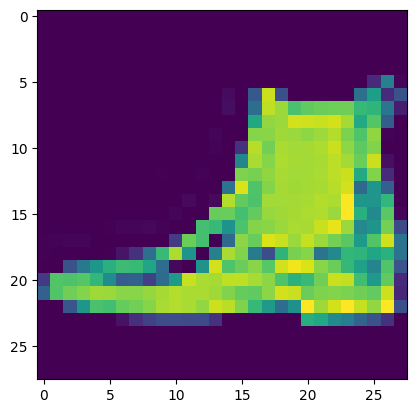

In [ ]:
exemplo_n = 5

# Imprime nome da classe da amostra 5
print(nomes_classes[y_train[exemplo_n]])

# Exibe a amostra 5 como imagem, com interpolação "nearest"
# para manter os pixels visivelmente separados
plt.imshow(X_train[exemplo_n], interpolation='nearest')
plt.show()

##  Rede Neural Artificial com Keras

In [ ]:
nn = keras.models.Sequential()

# Converte cada imagem 28x28 em um vetor unidimensional
nn.add(keras.layers.Flatten(input_shape=[28, 28]))

# 1ª camada oculta com 300 neurônios para extração inicial
nn.add(keras.layers.Dense(300, activation="relu"))

# Desliga aleatoriamente 10% dos neurônios durante o treinamento para reduzir overfitting
nn.add(keras.layers.Dropout(rate=0.1))

# 2ª camada oculta com 100 neruônios para aprender representações mais abstratas
nn.add(keras.layers.Dense(100, activation="relu"))

# Novo dropout de 10% para melhorar a capacidade de generalização
nn.add(keras.layers.Dropout(rate=0.1))

# Camada de saída com 10 neurônios, um para cada classe de objeto
nn.add(keras.layers.Dense(10, activation="softmax"))

nn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

A rede neural é composta por uma camada de entrada, duas camadas ocultas e uma camada de saída. Inicialmente, a camada Flatten transforma cada imagem de dimensão 28×28 pixels em um vetor unidimensional de 784 elementos, como demonstrado na saída da célula. Essa etapa é necessária porque as camadas densas operam sobre vetores e não sobre matrizes bidimensionais, que é o caso de imagens.

A primeira camada oculta possui 300 neurônios e utiliza a função de ativação ReLU, que foi escolhida por apresentar baixo custo computacional e minimizar o problema do desaparecimento do gradiente. O número de 300 neurônios provavelmente foi definido buscando extrair características relevantes sem aumentar excessivamente a complexidade do modelo.

Após essa camada, foi adicionada uma camada de Dropout com taxa de 10%, que desativa aleatoriamente parte dos neurônios durante o treinamento. Essa técnica reduz a dependência entre neurônios específicos e ajuda a evitar overfitting.

A segunda camada oculta contém 100 neurônios, também com função de ativação ReLU. A redução gradual do número de neurônios provavelmente foi adotada porque permite construir representações mais abstratas das características aprendidas na camada anterior, diminuindo também o número total de parâmetros do modelo.

A camada de saída é composta por 10 neurônios, que correspondem às dez classes possíveis para predição. A função de ativação Softmax converte as saídas em probabilidades, possibilitando que a classe prevista seja aquela de maior probabilidade.

### Compilando e treinando o modelo

In [ ]:
%time
# Compila o modelo
nn.compile(
  loss="sparse_categorical_crossentropy", # Função de perda adequada pra múltiplas classes
  optimizer="sgd",                        # Otimizador SGD pra ajuste de learning rate
  metrics=["accuracy"]                    # Define acurácia como métrica de validação
)

# Realiza o treinamento do modelo com os subconjuntos de treinamento e 5 épocas (passadas sobre o dataset)
history_nn = nn.fit(X_train, y_train, epochs=5, validation_data=(X_valid, y_valid))

CPU times: user 4 µs, sys: 0 ns, total: 4 µs
Wall time: 33.9 µs
Epoch 1/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7358 - loss: 0.7861 - val_accuracy: 0.8256 - val_loss: 0.5220
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8152 - loss: 0.5353 - val_accuracy: 0.8426 - val_loss: 0.4575
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8330 - loss: 0.4789 - val_accuracy: 0.8536 - val_loss: 0.4203
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8436 - loss: 0.4436 - val_accuracy: 0.8670 - val_loss: 0.3927
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8515 - loss: 0.4202 - val_accuracy: 0.8634 - val_loss: 0.3810


No treinamento, foi utilizada a função de perda `sparse_categorical_crossentropy`, adequada para problemas de classificação com múltiplas classes (nesse caso, 10) e rótulos inteiros, juntamente com o otimizador SGD (Stochastic Gradient Descent) e a métrica de acurácia. O SGD atualiza os pesos do modelo usando apenas um exemplo escolhido de forma aleatória a cada iteração, o que faz com que o modelo evite soluções subótimas. Essa escolha estocástica, porém, pode acabar gerando certo ruído, produzindo uma convergência instável. Além disso, a escolha de 5 épocas parece ser insuficiente, sendo que o ideal é escolher um valor acima de 20 e, nesse caso, usar um EarlyStopping para economizar tempo de treinamento.

### Visualizar a performance

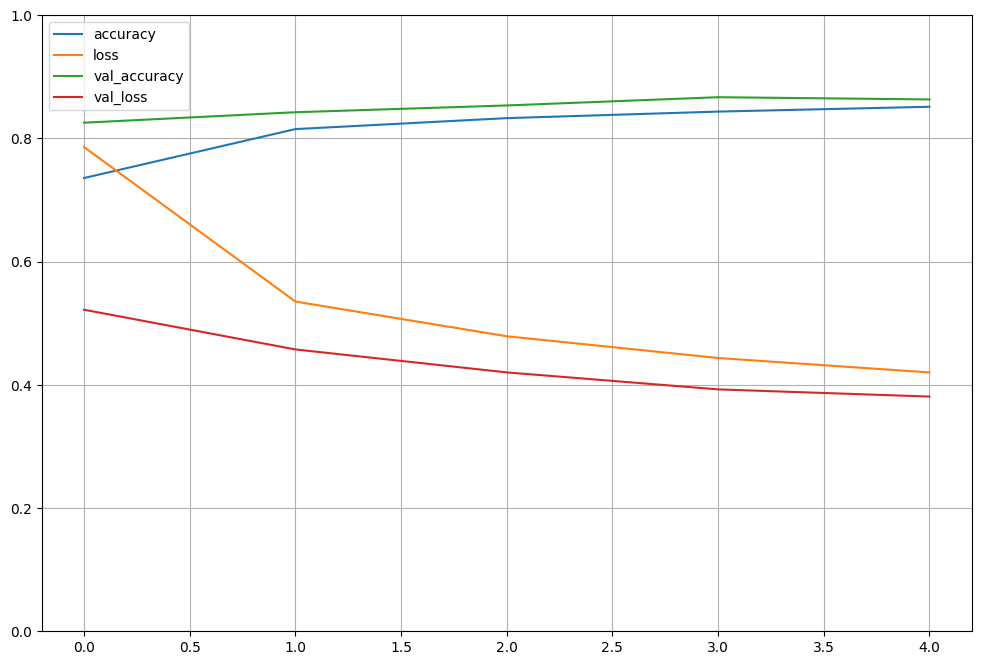

In [ ]:
# Transforma histórico do treinamento em dataframe
pd.DataFrame(history_nn.history).plot(figsize=(12, 8))

# Habilita grid na imagem
plt.grid(True)

# Altera escala do eixo y para intervalo [0,1]
plt.gca().set_ylim(0, 1)

# Exibe gráfico final de performance
plt.show()

As acurácias de treino e validação crescem conforme tempo de treinamento, sendo que, como esperado, a de validação é levemente mais estável. Com relação à perda, ambas baixaram conforme treinamento, mas a de treinamento demorou mais para alcançar certa estabilidade por conta do Dropout ativado, que, propositalmente, acaba gerando mais erro durante o treinamento para que o modelo se generalize.

### Avaliar o modelo

In [ ]:
# Imprime total de perda e acurácia para dados de TESTE
nn.evaluate(X_test, y_test,verbose=1) # Acurácia = 81,15%

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8115 - loss: 70.1111


[70.11112213134766, 0.8115000128746033]

###Realizar uma Previsão

In [ ]:
# Seleciona apenas as 4 primeiras imagens de TESTE
X_novo = X_test[:4]

# Realiza previsão das 4 imagens, produzindo uma matriz de probabilidades
y_proba = nn.predict(X_novo)

# Exibe matriz de probabilidades para cada uma das 10 classes
y_proba

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

Por ter sido usada a camada de saída Softmax com 10 neurônios, para cada amostra de entrada, é produzida uma lista de probabilidades, uma para cada classe de objeto. Dessa forma, o resultado da célula é uma matriz 4x10, sendo que, para cada linha (amostra), a rede demonstrou 100% de probabilidade para a classe prevista.

In [ ]:
# Faz novamente a previsão, dessa vez selecionando a classe com maior probabilidade
y_pred = np.argmax(nn.predict(X_novo), axis=-1)

# Imprime número das classes prevista
print(y_pred)

# Imprime nome de cada classe prevista
print(np.array(nomes_classes)[y_pred])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
[9 2 1 1]
['bota' 'casaco' 'calca' 'calca']


### Verificar os resultados

In [ ]:
# Recupera rótulos reais das 4 primeiras imagens do conjunto de TESTE
y_novo = y_test[:4]

# Imprime número dos rótulos
print(y_novo)

# Imprime nome das classes
np.array(nomes_classes)[y_pred]

[9 2 1 1]


array(['bota', 'casaco', 'calca', 'calca'], dtype='<U10')

calca


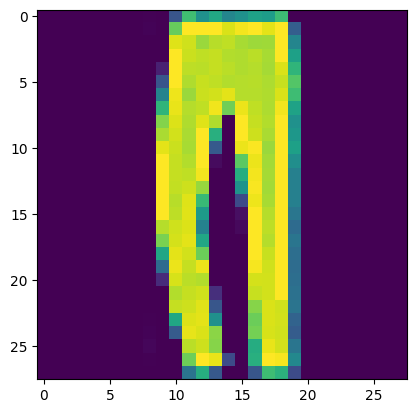

In [ ]:
# Imprime nome da classe prevista para 2ª amostra
print(nomes_classes[y_pred[2]])

# Exibe imagem de entrada da 2ª amostra
plt.imshow(X_novo[2], interpolation='nearest')
plt.show()

## Treinando CNN com Keras

In [ ]:
cnn = keras.models.Sequential([

    # Entrada das imagens em escala de cinza: 28x28 pixels e 1 canal (grayscale)
    keras.layers.InputLayer(input_shape=(28,28,1)),

    # Camada de convolução com 64 filtros 5x5 pra características básicas
    keras.layers.Conv2D(
        64, 5,
        activation='relu',
        padding='same',
        kernel_initializer='glorot_uniform'),

    # Camada de Max Pooling com janela 2x2 pra reduzir mapa de características
    keras.layers.MaxPool2D(2),

    # Camada de convolução com 128 filtros 3x3 pra características mais complexas
    keras.layers.Conv2D(128, 3, activation='relu', padding='same'),

    # Camada igual pra refinamento das características extraídas
    keras.layers.Conv2D(128, 3, activation='relu', padding='same'),

    # Nova camada pra redução da dimensão espacial
    keras.layers.MaxPool2D(2),

    # Extração de características de alto nível
    keras.layers.Conv2D(258, 3, activation='relu', padding='same'),

    # Refinamento das características profundas
    keras.layers.Conv2D(258, 3, activation='relu', padding='same'),

    # Última redução espacial
    keras.layers.MaxPool2D(2),

    # Converte os mapas de características em vetor unidimensional
    keras.layers.Flatten(),

    # Combina as características extraídas para classificação
    keras.layers.Dense(128, activation="relu"),

    # Regularização de 50% contra overfitting
    keras.layers.Dropout(rate=0.5),

    keras.layers.Dense(64, activation="relu"),

    # Última regularização de 50%
    keras.layers.Dropout(rate=0.5),

    # 10 neurônios para as 10 classes de objeto
    keras.layers.Dense(10, activation="softmax")
])

Neste segundo modelo, diferentemente do primeiro, a arquitetura é de uma CNN formada por três blocos convolucionais seguidos por duas camadas densas. A camada de entrada recebe imagens em escala de cinza de dimensão 28×28 pixels.

A primeira camada convolucional possui 64 filtros de tamanho 5×5 e função de ativação ReLU. O kernel de 5x5 poderia ser 3x3, porque kernels menores extraem mais detalhes locais. Seu objetivo é detectar características básicas da imagem, como bordas, contornos e texturas. O preenchimento `same` foi utilizado para preservar as dimensões espaciais da imagem durante a convolução.

Após essa etapa, a camada de Max Pooling com janela 2×2 permite reduzir a resolução espacial dos mapas de características pela metade, diminuindo a quantidade de parâmetros.

O segundo bloco convolucional é composto por duas camadas com 128 filtros 3×3, responsáveis por aprender características mais complexas a partir das extrações realizadas anteriormente. Em seguida, um novo Max Pooling reduz novamente as dimensões espaciais, priorizando características mais relevantes.

O terceiro bloco repete essa estratégia utilizando duas camadas convolucionais com 258 filtros 3×3, permitindo que a rede capture padrões de maior nível semântico. O parâmetro 258 poderia ser definido como 256, porque seria exatamente o dobro dos filtros utilizados nos blocos de convolução anteriores, mantendo uma progressão natural. Após a última operação de Max Pooling, os mapas de características são convertidos em um vetor unidimensional pela camada Flatten.

As camadas densas de 128 e 64 neurônios, ambas com função ReLU, realizam a combinação das características extraídas pelas camadas convolucionais. Entre elas foram inseridas camadas Dropout com taxa de 50% a fim de reduzir o overfitting, tornando o modelo mais adaptável a dados genéricos. No entanto, o valor de 50% pode ser um pouco agressivo, visto que metade dos neurônios seriam desligados. Nesse caso, talvez 20% ou 30% seriam valores mais adequados.

Por fim, a camada de saída possui 10 neurônios e função Softmax, como no modelo anterior, produzindo uma distribuição de probabilidades correspondente às dez classes de objetos do Fashion-MNIST.

In [ ]:
# Exibe camadas da CNN, cada qual com shape e número de parâmetros
cnn.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 14, 14, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 7, 7, 258)      │       297,474 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 7, 7, 258)      │       599,334 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 3, 3, 258)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 2322)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │       297,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,426,162 (5.44 MB)

 Trainable params: 1,426,162 (5.44 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Imprime dimensões originais do tensor de treinamento
print(X_train.shape) # 3 dimensões: amostras, largura, altura

# Redimensiona tensor de TREINO para 4 dimensões
X_train_new = X_train.reshape(X_train.shape[0], X_train.shape[1], X_train.shape[2],1)

# Redimensiona tensor de VALIDAÇÃO para 4 dimensões
X_valid_new = X_valid.reshape(X_valid.shape[0], X_valid.shape[1], X_valid.shape[2],1)

# Redimensiona tensor de TESTE para 4 dimensões
X_test_new = X_test.reshape(X_test.shape[0], X_test.shape[1], X_test.shape[2],1)

# Imprime dimensões do tensor de treino ajustado
print(X_train_new.shape)

(55000, 28, 28)
(55000, 28, 28, 1)


O reajuste foi necessário porque as camadas de convolução esperam uma entrada de 4 dimensões: número de amostras, largura, altura e canais. Como as imagens estão em escala cinza (grayscale), todas recebem 1 canal na última dimensão.

In [ ]:
# Compila o modelo, mantendo parâmetros do anterior
cnn.compile(
  loss="sparse_categorical_crossentropy",   # Perda adequada para múltiplas classes
  optimizer="sgd",                          # Otimizador SGD
  metrics=["accuracy"]                      # Métrica de acurácia pra validação
)

# Treina o modelo com os tensores ajustados de TREINO e VALIDAÇÃO e 20 épocas
history_cnn = cnn.fit(X_train_new, y_train, epochs=20, validation_data=(X_valid_new, y_valid))

Epoch 1/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 712s 413ms/step - accuracy: 0.4906 - loss: 1.3635 - val_accuracy: 0.7598 - val_loss: 0.7174
Epoch 2/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 716s 417ms/step - accuracy: 0.7062 - loss: 0.7983 - val_accuracy: 0.7984 - val_loss: 0.5547
Epoch 3/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 738s 415ms/step - accuracy: 0.7631 - loss: 0.6608 - val_accuracy: 0.8226 - val_loss: 0.4731
Epoch 4/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 718s 418ms/step - accuracy: 0.7935 - loss: 0.5809 - val_accuracy: 0.8478 - val_loss: 0.4163
Epoch 5/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 721s 420ms/step - accuracy: 0.8119 - loss: 0.5306 - val_accuracy: 0.8522 - val_loss: 0.3959
Epoch 6/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 740s 419ms/step - accuracy: 0.8269 - loss: 0.4949 - val_accuracy: 0.8658 - val_loss: 0.3767
Epoch 7/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 734s 414ms/step - accuracy: 0.8371 - loss: 0.4656 - val_accuracy: 0.8732 - val_loss: 0.3604
Epoch 8/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 749s 418ms/step - ac

Os parâmetros do modelo anterior foram mantidos na compilação da CNN, ainda que, como sugerido antes, o otimizador SGD pudesse ser trocado pelo Adam para uma convergência mais estável. Por outro lado, o treinamento desta vez utilizou 20 épocas, o que já é mais adequado para o problema em relação às 5 da anterior. No entanto, para 20 épocas o mais o ideal seria utilizar um EarlyStopping, visando economizar custo computacional e tempo de treinamento quando não houver melhora.

### Avaliar o modelo

In [ ]:
cnn.evaluate(X_test_new, y_test,verbose=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 120ms/step - accuracy: 0.8735 - loss: 28.0920


[28.091962814331055, 0.8734999895095825]

Os resultados evidenciam um desempenho superior da rede neural convolucional em comparação com a MLP. Enquanto a MLP atingiu aproximadamente 81% de acurácia, a CNN alcançou 87,35%, indicando maior capacidade de generalização e classificação das imagens do conjunto Fashion-MNIST. Além disso, observou-se uma redução significativa da função de perda, sugerindo que as previsões realizadas pela CNN apresentaram menor erro médio durante o processo de classificação. Esse ganho pode ser atribuído à capacidade das camadas convolucionais de explorar as relações espaciais entre os pixels e extrair automaticamente características relevantes das imagens, algo que não ocorre na MLP, que recebe apenas um vetor unidimensional após a etapa de achatamento (flattening).

Em contrapartida, o aumento da complexidade arquitetural implicou em um maior custo computacional. O treinamento da CNN demandou aproximadamente quatro horas com CPU, tempo substancialmente superior ao da MLP, por conta da maior quantidade de parâmetros e operações convolucionais realizadas. Além disso, o treinamento foi executado sem a utilização de técnicas como EarlyStopping, o que pode ter contribuído para a execução de épocas adicionais sem ganhos significativos de desempenho.

Embora a CNN tenha apresentado desempenho superior à MLP, os resultados obtidos ainda podem ser aprimorados por meio do ajuste de hiperparâmetros e da adoção de técnicas adicionais de regularização e otimização, como EarlyStopping, BatchNormalization e o otimizador Adam. Essas estratégias tendem a acelerar a convergência e elevar a acurácia do modelo, mantendo um custo computacional mais equilibrado.

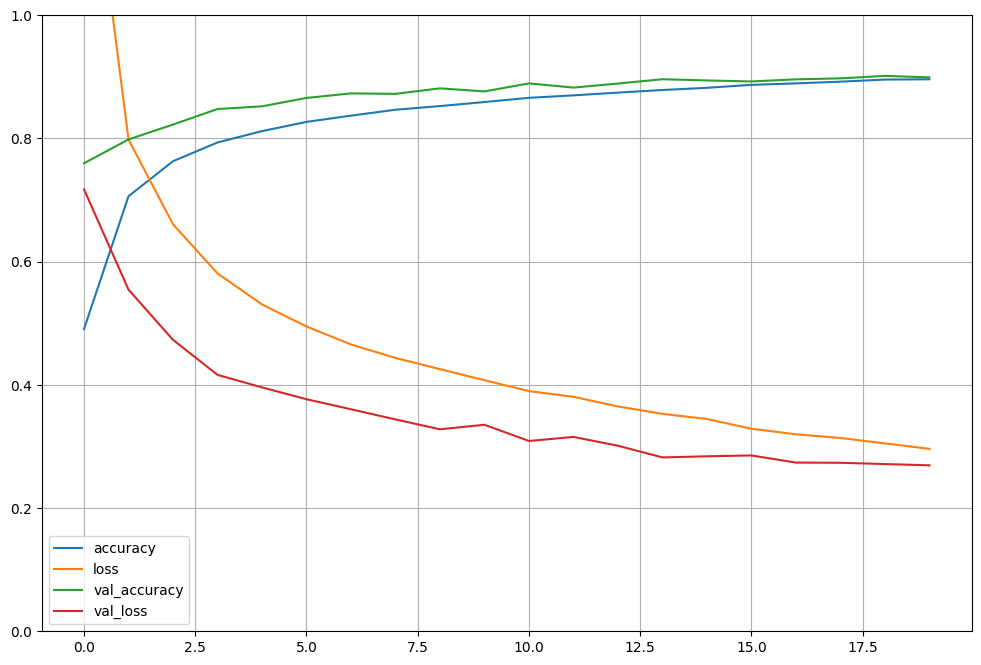

In [ ]:
# Cria um dataframe do histórico de desempenho da CNN
pd.DataFrame(history_cnn.history).plot(figsize=(12, 8))

# Habilita grades no gráfico
plt.grid(True)

# Ajusta intervalo do eixo y para [0,1]
plt.gca().set_ylim(0, 1)

# Exibe gráfico
plt.show()

O gráfico apresenta a evolução das métricas de treinamento e validação da rede neural convolucional ao longo das épocas de treinamento. Verifica-se um aumento gradual da acurácia tanto no conjunto de treinamento quanto no de validação, atingindo aproximadamente 90% ao final do processo. Simultaneamente, as curvas de perda apresentam comportamento decrescente, evidenciando a convergência do algoritmo de aprendizado.

A proximidade entre as curvas de treinamento e validação indica boa capacidade de generalização do modelo e ausência de sinais expressivos de overfitting. Além disso, observa-se que as maiores melhorias ocorreram nas primeiras épocas, enquanto nas épocas finais os ganhos foram bem menos significativos. Esse comportamento sugere que a utilização de mecanismos como EarlyStopping poderia ter reduzido o tempo de treinamento sem comprometer o desempenho final.